In [2]:
! pip install numpy scipy matplotlib

Defaulting to user installation because normal site-packages is not writeable


# Questão 2.2


## 2.2.2. 
Usando o esquema numérico de Crank-Nicolson resolve o problema mixto para a equa ̧c ̃ao paraxial no dominio $Ω = {(x, z)|x ∈ [0, 3000], z ∈ [0, 500]}$ de forma seguinte:

- a equação:

$$iu_x + bu_{zz} + Vu = 0$$

- os coeficientes:

$$b
 = 5$$ 

$$V (z) = exp [-\frac{ 
(z − 250)^2}
{30000}] $$


- as condiçoes de contorno:
 $$u(x, 0) = u(x, L) =
  0$$
onde $$L = 
500$$ ,
- a condi ̧c ̃ao inicial:

$$u(0, z) = u_0(z) = exp(iz/4) exp [-\frac{
(z − 250)2}
{1500}] $$
.

Dica: pode usar passos ∆x = 5, ∆z = 1.

Primeiramente vamos definir o stencil 

In [55]:

import numpy as np
from scipy.sparse import diags
from scipy.sparse.linalg import spilu
from matplotlib import pyplot as plt


x_max = 3000
z_max = 500

delta_x = 5 
delta_z = 1
n_x = int(x_max/delta_x) # Número de pontos do stenccil em x
n_z = int(z_max/delta_z) # Número de pontos do stenccil em y
x = np.linspace(0, x_max, n_x)
z = np.linspace(0, z_max, n_z)

X, Z = np.meshgrid(x,z)



def V(z):
    return np.exp(-(z - 250)**2 / 30000)

def condicao_inicial(z):
    return np.exp(1j * z / 4) * np.exp(-((z - 250)**2) / 1500)

b = 5



No nosso esquema, temos uma recorrencia da seguinte forma:

$$A r_{n+1}  = B r_{n}$$

Onde $r_n$ representa o vetor:


$$r_n = 
\begin{pmatrix} 
u(x_n, z_0) = u_{n,0}\\
u(x_n, z_1) = u_{n,1}\\
\vdots \\ 
u(x_n, z_i) = u_{n,i}\\
\vdots \\
\end{pmatrix}
$$


$$x_n = x_0 + n*\Delta x$$
$$z_i = z_0 + i*\Delta z $$


Como o potencial não depende de x, e como a matriz de propragação $ A^{-1} C $ ( sabemos que $A$ tem inversa) apresentam dependencia de $x$ ( e consequentemente $n$ ) apenas devido ao potencial, então podemos concluir que a matriz é  a mesma para todo $n$. Portanto, basta inverter a e calcular o produto $A^{-1}C$ uma vez


Em nosso esquema:

$$C_{00}=A_{00} = 1$$
e 
$$
C_{0k}=A_{0k} =0 $$ 
para $k\not= 0$ 

$$A_{(J-1)(J-1)}= A_{(J-1)(J-1)} = 1 $$
e
$$C_{k(J-1)} =A_{k(J-1)} = 0$$
para $k\not= J-1$

Onde $J$ é número de pontos $z$ da grade

Daí 

$$A_{jj} = \frac{i}{\Delta x} + \frac{V_j}{2} - \frac{b}{\Delta z ^2 }$$

para $j$ entre $1$ e $J-2$

Já a diagonal de baixo é: 
$$A_{(j+1)j} = \frac{b}{2\Delta z ^2}$$
para $j$ entre $0$ e $J-3$. 

A de cima é:
$$A_{(j-1)j} = \frac{b}{2\Delta z ^2}$$
para $j$ entre $2$ e $J-1$

e

$$C_{jj} = \frac{i}{\Delta x} - \frac{V_j}{2} + \frac{b}{\Delta z ^2 }$$

Já a diagonal de baixo é: 
$$C_{(j+1)j} = -\frac{b}{2\Delta z ^2}$$
para $j$ entre $0$ e $J-3$. 

A de cima é:
$$C_{(j-1)j} = -\frac{b}{2\Delta z ^2}$$
para $j$ entre $2$ e $J-1$





A matriz $A$:

$$
A =
\begin{pmatrix}
1 & 0 & 0 & \cdots & 0 & 0 \\

\frac{b}{2\Delta z^2} &
\frac{i}{\Delta x} + \frac{V_1}{2} - \frac{b}{\Delta z^2} &
\frac{b}{2\Delta z^2} &
\cdots & 0 & 0 \\

0 &
\frac{b}{2\Delta z^2} &
\frac{i}{\Delta x} + \frac{V_2}{2} - \frac{b}{\Delta z^2} &
\ddots & 0 & 0 \\

\vdots & \ddots & \ddots & \ddots &
\frac{b}{2\Delta z^2} & 0 \\

0 & 0 & 0 &
\frac{b}{2\Delta z^2} &
\frac{i}{\Delta x} + \frac{V_{J-2}}{2} - \frac{b}{\Delta z^2} &
\frac{b}{2\Delta z^2} \\

0 & 0 & 0 & 0 & 0 & 1
\end{pmatrix}
$$



A matriz $C$:

$$
C =
\begin{pmatrix}
1 & 0 & 0 & \cdots & 0 & 0 \\

-\frac{b}{2\Delta z^2} &
\frac{i}{\Delta x} - \frac{V_1}{2} + \frac{b}{\Delta z^2} &
-\frac{b}{2\Delta z^2} &
\cdots & 0 & 0 \\

0 &
-\frac{b}{2\Delta z^2} &
\frac{i}{\Delta x} - \frac{V_2}{2} + \frac{b}{\Delta z^2} &
\ddots & 0 & 0 \\

\vdots & \ddots & \ddots & \ddots &
-\frac{b}{2\Delta z^2} & 0 \\

0 & 0 & 0 &
-\frac{b}{2\Delta z^2} &
\frac{i}{\Delta x} - \frac{V_{J-2}}{2} + \frac{b}{\Delta z^2} &
-\frac{b}{2\Delta z^2} \\

0 & 0 & 0 & 0 & 0 & 1
\end{pmatrix}
$$


In [56]:
V_j = V(z)



def fazer_matriz(J, V_j, dx, dz, b):
    
    # V_j é um vetor 
    diag_A = np.zeros(J, dtype=complex)
    diag_C = np.zeros(J, dtype=complex)

    diag_A[0] = 1.0
    diag_C[0] = 1.0

    diag_A[-1] = 1.0
    diag_C[-1] = 1.0

    diag_A[1:-1] = 1j/dx + V_j[1:-1]/2 - b/dz**2
    diag_C[1:-1] = 1j/dx - V_j[1:-1]/2 + b/dz**2

    diag_baixo_A = np.ones(J-1,dtype=complex)*b/(2*dz**2)
    diag_baixo_A[-1] = 0
    diag_cima_A = np.ones(J-1,dtype=complex)* b/(2*dz**2)
    diag_cima_A[0] = 0

    diag_baixo_C = -np.ones(J-1,dtype=complex)*b/(2*dz**2)
    diag_baixo_C[-1] = 0
    diag_cima_C = -np.ones(J-1,dtype=complex)* b/(2*dz**2)
    diag_cima_C[0] = 0

    A = diags([diag_baixo_A, diag_A, diag_cima_A], [-1,0,1], format = "csc")
    C = diags([diag_baixo_C, diag_C, diag_cima_C], [-1,0,1], format = "csc")
    A_info = {
    "matriz_esparsa": A,
    "diag_cima": diag_cima_A,
    "diag": diag_A,
    "diag_baixo": diag_baixo_A
    }

    C_info = {
        "matriz_esparsa": C,
        "diag_cima": diag_cima_C,
        "diag": diag_C,
        "diag_baixo": diag_baixo_C
    }

    return A_info, C_info

A_info,C_info = fazer_matriz(J= n_z, V_j=V_j, dx = delta_x, dz = delta_z, b= b)

    




Aqui conseguimos então gerar as duas matrizes, elas são salvas de forma esparsa.

Para reolver o problema vamos implementar o algoritimo de thomas para resolver 

![Texto Alternativo](thomas.png)


imagem de https://pt.wikipedia.org/wiki/Algoritmo_de_Thomas

In [57]:
def resolver_thomas(cima, baixo, meio, y):
    #Ax = y
    
    J = len(meio)
    d = meio.astype(complex).copy()
    c = cima.astype(complex).copy()
    b = baixo.astype(complex).copy()
    yf = y.astype(complex).copy()

    for j in range(1, J):
        m = b[j-1] / d[j-1]
        d[j] = d[j] - m * c[j-1]
        yf[j] = yf[j] - m * yf[j-1]
    #Voltando 
    x = np.zeros(J, dtype=complex)
    x[-1] = yf[-1] / d[-1]

    for j in range(J-2, -1, -1):
        x[j] = (yf[j] - c[j] * x[j+1]) / d[j]

    return x




Por fim vamos apenas aplicar o algoritimo

In [58]:
r_0 = condicao_inicial(z=z)

def operar(A_info,C, r_n):
    A_cima = A_info["diag_cima"]
    A_baixo = A_info["diag_baixo"]
    A_meio = A_info["diag"]
    y = C@r_n
    r_n_mais_1 = resolver_thomas(cima =A_cima, baixo=A_baixo,meio=A_meio, y=y )
    return r_n_mais_1

# Determinar um x_n
def x_n(A_info,C, r0, n):
    r_atual = r0.astype(complex).copy()
    if n < 0 or n >= n_x:
        return None
    if n == 0:
        return r0
    for _ in range(n):
        r_atual = operar(A_info=A_info, C=C,r_n= r_atual)

    return r_atual

x_1 = x_n(A_info=A_info, C= C_info["matriz_esparsa"], r0= r_0, n=1 )



Pode ser útil determinar uma função para observar toda a evolução 



In [72]:
def evolucao_completa(A_info, C, r0, n_x):

    J = len(r0)
    R = np.zeros((n_x, J), dtype=complex)
    R[0] = r0.astype(complex)
    
    r_atual = R[0].copy()
    
    for n in range(1,n_x):
        r_atual = operar(A_info=A_info, C=C, r_n=r_atual)
        R[n] = r_atual
    
    return R

R = evolucao_completa(A_info=A_info, C= C_info["matriz_esparsa"], r0=r_0, n_x=n_x)
mod = np.abs(R)
mod = mod.T

Vamos usar um mapa de calor para verificar $||u(x,y)||^2$

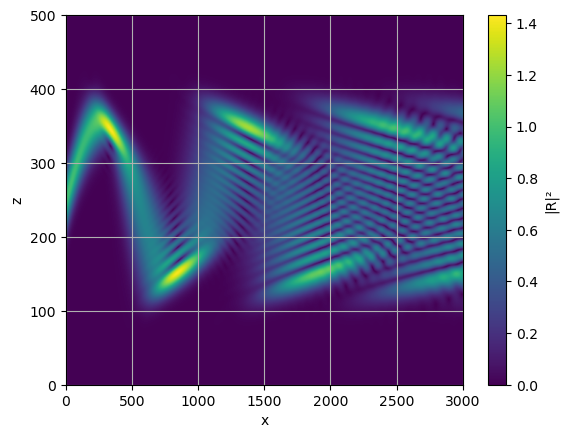

In [75]:
plt.imshow(mod,
           extent=[0, x_max, 0, z_max],
           origin="lower",
           aspect="auto")

plt.xlabel("x")
plt.ylabel("z")
plt.grid()
plt.colorbar(label="|R|²")
plt.show()



Podemos também verificar a função densidade de probabilidade para cada secção vertical. 

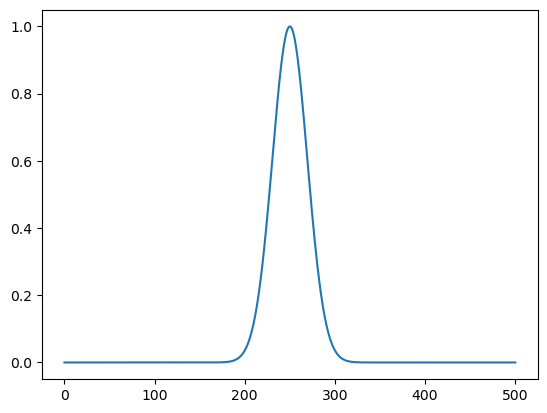

In [9]:
#Lembrar de divitir por 5 o número no gráfico 
condicao_inicial_modulo = np.abs(R[0,:])**2
plt.plot(z, condicao_inicial_modulo)
plt.show()


Além disso, o método deve manter a norma da probabilidade para cada x constante conforme a propagação na direção x. Podemos então analisar essa norma.

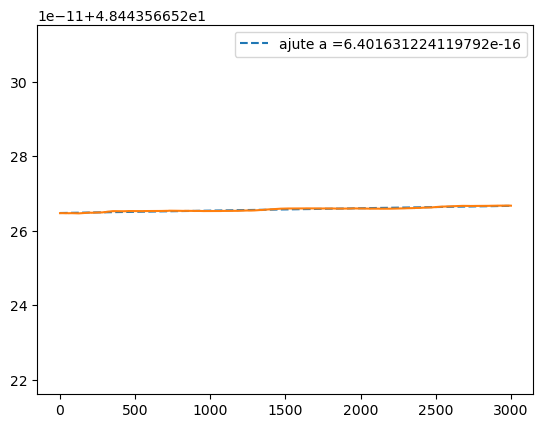

In [10]:
norma = np.sum(np.abs(R)**2, axis=1)
a,b  = np.polyfit(x, norma, 1)
plt.plot(x, a*x+b,linestyle= "--", label= f"ajute a ={a}")
plt.plot(x,norma)

plt.legend()
plt.show()


Percebemos que o processo númerico está, pelo menos, preservando a norma a cada operação.

## 2.2.4

Crie o gráfico da funcão $\sqrt(1+x)$ e suas aproximações por Taylor de 1ª, 2ª e 4ª ordem e por Padé de
ordem (1, 1) (Claerbout) e (2, 2).

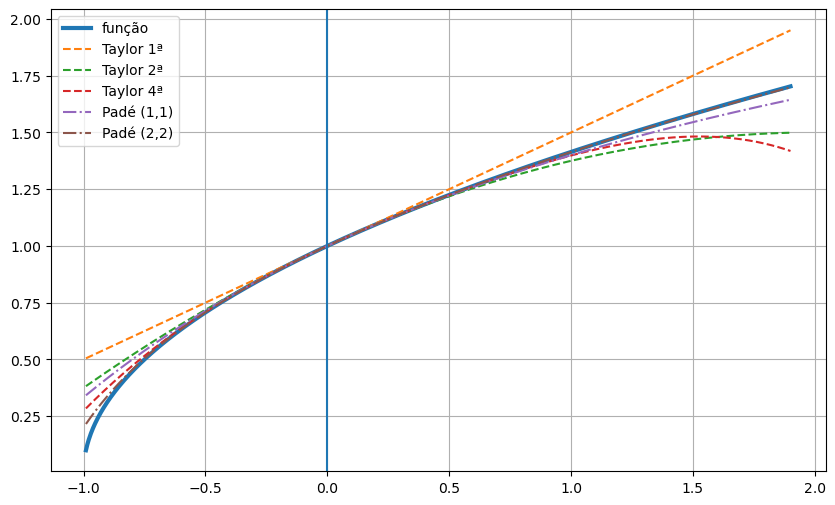

In [11]:
import numpy as np
import matplotlib.pyplot as plt


x = np.linspace(-0.99, 1.9, 1000) # Indo para perto da singulardade afim de observar a convergência das aproximações
def func(x):
    return np.sqrt(1+x)

f = func(x)

# 1ª ordem
T1 = 1 + x/2
# 2ª ordem
T2 = 1 + x/2 - x**2/8
# 4ª ordem
T4 = 1 + x/2 - x**2/8 + x**3/16 - 5*x**4/128
# Padé (1,1)
P11 = (1 + (3/4)*x) / (1 + (1/4)*x)
# Padé (2,2)
P22 = (1 + (5/4)*x + (5/16)*x**2) / (1 + (3/4)*x + (1/16)*x**2)


plt.figure(figsize=(10, 6))
plt.plot(x, f, label='função', linewidth=3)
plt.plot(x, T1, '--', label='Taylor 1ª')
plt.plot(x, T2, '--', label='Taylor 2ª')
plt.plot(x, T4, '--', label='Taylor 4ª')
plt.plot(x, P11, '-.', label='Padé (1,1)')
plt.plot(x, P22, '-.', label='Padé (2,2)')
plt.axvline(0)
plt.grid()
plt.legend()

plt.show()


Note que a aproximação de Padé (2,2) tem uma boa aproximação até próximo a sigularidade e em pontos mais distantes de 0. Diferente, por exemplo, da aproximação por Taylor.
Vamos observar o gráfico de erro absoluto.

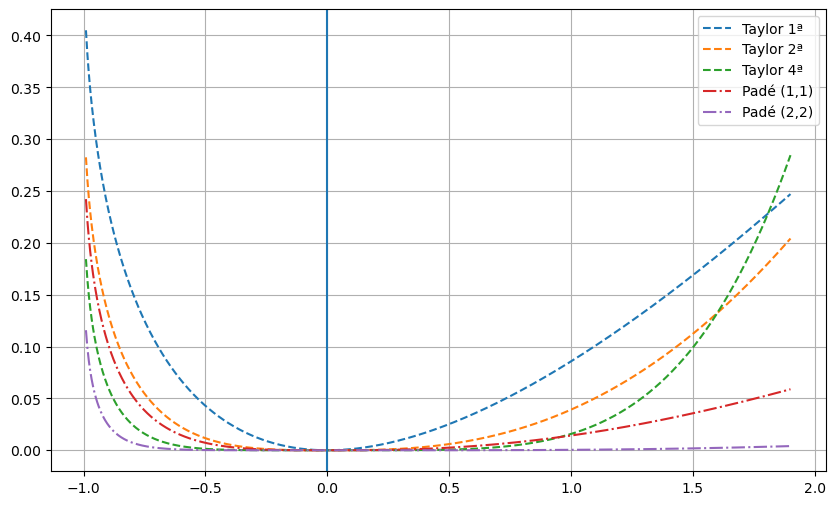

In [12]:
plt.figure(figsize=(10, 6))

plt.plot(x, np.abs(T1 -f), '--', label='Taylor 1ª')
plt.plot(x, np.abs(T2-f), '--', label='Taylor 2ª')
plt.plot(x, np.abs(T4-f), '--', label='Taylor 4ª')
plt.plot(x, np.abs(P11-f), '-.', label='Padé (1,1)')
plt.plot(x, np.abs(P22-f), '-.', label='Padé (2,2)')
plt.axvline(0)
plt.grid()
plt.legend()

plt.show()


Aqui conseguimos ver claramente como Padé (2,2) aproxima bem pontos mais longes em comparação com as outras séries.

# 5.1 Modelagem de Sinal de Radar

Utilizando o modelo da equação de Claerbout de grande abertura, o campo elétrico  
$$
u(x,z) = E_y(x,z)$$  
na atmosfera sobre a superfície do mar é dado por:

Considere o domínio de propagação

$$
\Omega = \{(x,z) \mid z \in [0,H], \; x \in [0,X]\}
$$

onde:

- $$z = H = 200\,\text{m}
$$ 
é uma fronteira transparente (utilize PML para truncar o domínio);
- $$z = 0
$$ 
é a superfície do mar, onde se impõe a condição de Dirichlet:

$$
u(x,0) = 0.
$$

O campo satisfaz a equação de Helmholtz:

$$
u_{xx} + \nu_{zz} + k^2 (1 + n)u = -\delta(x)Q(z),
$$

onde

$$
k = \frac{2\pi f}{c},
$$

sendo $$f$$ a frequência, $$c$$ a velocidade da luz no vácuo,  
$$n(x,z)$$ o quadrado do índice de refração e $$Q(z)$$ a diretividade da fonte (antena parabólica):

$$
Q(z) =
A \frac{k\beta}{2\sqrt{\pi \log_{10} 2}}
\exp(-ik\theta_0 z)
\exp\left(
-\frac{\beta^2}{8 \log_{10} 2} k^2 (z - z_0)^2
\right).
$$

Onde:

- $$\theta_0
$$ 
é o ângulo de elevação do feixe;
- $$z_0 = 10\,\text{m}
$$
 é a altitude da antena;
- $$\beta = 35^\circ
$$ 
descreve a largura do feixe.

**Dica:** na formulação da equação de Claerbout, a função $$Q(z)$$ é utilizada como condição inicial:

$$
u(0,z) = u_0(z) = Q(z).
$$

Defina a frequência:

$$
f = 300\,\text{MHz}
$$

(valor inferior às frequências típicas de radar, adotado para acelerar os cálculos).

Os cálculos devem ser realizados até

$$
X = 20\,\text{km}
$$

para

$$
\theta_0 = 5^\circ, \; 10^\circ, \; 20^\circ.
$$

Os resultados devem ser apresentados na forma de gráfico de contorno  
(utilizar `imagesc()` no MATLAB), onde as cores representam a intensidade do campo em dB, isto é:

$$
20 \log_{10} |u(x,z)|.
$$

Ajuste a escala de cores de forma que ela abranja valores típicos no domínio.


![Texto Alternativo](esquema.png)


Vamos considerar apenas a propragação para direita.

$$ \frac{\partial u}{\partial x} = i \sqrt{ k^2(1+n(x,z)) + \frac{\partial^2}{\partial z^2} } \, u. $$
e 
$$u(0,z) = Q(z)$$

A aproximação de Padé (1,1) para o operador raiz fornece:

$$
\frac{\partial u}{\partial x}
=
i k
\frac{
1 + \frac{1}{4}\left(
n(x,z) + \frac{1}{k^2}\frac{\partial^2}{\partial z^2}
\right)
}{
1 - \frac{1}{4}\left(
n(x,z) + \frac{1}{k^2}\frac{\partial^2}{\partial z^2}
\right)
}
\, u(x,z).
$$

Para simplificar

$$
\frac{\partial u}{\partial x}
=
i k
\frac{
1 + \hat X /4
}{
1 - \hat X /4
}
\, u(x,z).


$$

$$\hat X =  \left(n(x,z) + \frac{1}{k^2}\frac{\partial^2}{\partial z^2}\right)$$

Note que a aproximação de Padé(1,1) é similar a tranformação de Cayley de um operador hermitiano. O que nos leva a concluir que a aproximação conserva a norma, como vimos em outra questão.


Quando discretizamos a malha, tomando $u_x = \frac{u_{n+1, j}- u_{n,j}}{\Delta x}$ e $u = \frac{u_{n+1, j}+ u_{n,j}}{2}$ 

Obtemos 

$$(2 -  \hat X/2 -i\Delta x k (1+ \hat X /4 )) u_{n+1, j} = (2 -  \hat X /2 + i\Delta x k (1+ \hat X /4))  u_{n,j}$$

$$\alpha = i\Delta x k/2$$
$$(1 -  \hat X/4 -  \alpha(1+ \hat X/4)) u_{n+1, j} = (1 -  \hat X/4 +  \alpha (1+ \hat X/4))  u_{n,j}$$





Matriz A

$$
A = 1-\frac14 X-\alpha-\frac{\alpha}{4}X
$$

Agrupando termos:

$$
A = (1-\alpha) - \frac14(1+\alpha)X.
$$


$$
B = 1-\frac14 X+\alpha+\frac{\alpha}{4}X
$$

Agrupando:

$$
B = (1+\alpha) - \frac14(1-\alpha)X.
$$





Definimos, sabendo que n não depende de x. 

$$
X = 1/4(n(z) + \frac{1}{k^2}\partial_z^2).
$$

A derivada segunda na malha é

$$
\partial_z^2 u_j
=
\frac{u_{j+1}-2u_j+u_{j-1}}{\Delta z^2}.
$$

Definindo

$$
\gamma = \frac{1}{k^2 \Delta z^2},
$$

obtemos

$$
X u_j =
1/4((n_j - 2\gamma)u_j
+ \gamma u_{j+1}
+ \gamma u_{j-1}).
$$

Logo, $$X$$ é uma matriz tridiagonal com:

- Diagonal principal: $$ n_j - 2\gamma $$
- Sub e superdiagonal: $$ \gamma $$


$$
A = (1-\alpha)I - \frac14(1+\alpha)X.
$$

Diagonal principal

$$
A_{jj}
=
(1-\alpha)
-\frac14(1+\alpha)(n_j - 2\gamma).
$$

Expandindo:

$$
A_{jj}
=
(1-\alpha)
-\frac14(1+\alpha)n_j
+\frac12(1+\alpha)\gamma.
$$

Sub e superdiagonal

$$
A_{j,j\pm1}
=
-\frac14(1+\alpha)\gamma.
$$



$$
C = (1+\alpha)I - \frac14(1-\alpha)X.
$$

Diagonal principal

$$
C_{jj}
=
(1+\alpha)
-\frac14(1-\alpha)(n_j - 2\gamma).
$$

Expandindo:

$$
C_{jj}
=
(1+\alpha)
-\frac14(1-\alpha)n_j
+\frac12(1-\alpha)\gamma.
$$

 Sub e superdiagonal

$$
C_{j,j\pm1}
=
-\frac14(1-\alpha)\gamma.
$$





Para cada ponto interno $$j$$:

$$
A_{j,j-1}u^{n+1}_{j-1}
+
A_{jj}u^{n+1}_j
+
A_{j,j+1}u^{n+1}_{j+1}
=
C_{j,j-1}u^{n}_{j-1}
+
C_{jj}u^{n}_j
+
C_{j,j+1}u^{n}_{j+1}.
$$

onde

$$
\alpha = \frac{ik\Delta x}{2},
\qquad
\gamma = \frac{1}{k^2\Delta z^2}.
$$




Note que isso são para pontos fora do contorno $j \not = 0, H/\Delta z - 1$. A condição de contorno em $j=0$ é a que a já usamos antes. Porém agora precisamos usar o PML para a borda de cima.

In [41]:
f = 300 * 10**6 #Hz
c =3*10**8 #Hz
k = 2*np.pi*f/c
# comprimento de onda é 
lamb = c/f
dz = lamb/10 # 10 pontos por comprimento de onda 
dx = 0.5/k

f = 300e6
beta = np.deg2rad(35) # Esse beta é o do enunciano

theta_0 = np.deg2rad(5)   # ou 10 ou 20

z0 = 10.0

Amp = 1.0



Definido os passos, vamos definir a grid.

In [51]:
H = 200
X = 20*10**3
Delta = 20
Nz = int(H/dz)
Nx = int(X/dx)
z_extendido = np.linspace(0,H, Nz)
x = np.linspace(0, X, Nx)

def n(z):
    n = np.zeros_like(z)
    mask =  z <= 100
    n[mask] = -1 + z[mask]/100
    return n

def Q(z, A, k, beta, theta_0, z0):
    # Constantes e termos iniciais
    log10_2 = np.log10(2)
    
    # Termo de amplitude (coeficiente)
    amplitude = A * (k * beta) / (2 * np.sqrt(np.pi) * log10_2)
    
    # Primeiro termo exponencial: exp(-i * k * theta_0 * z)
    phase_term = np.exp(-1j * k * theta_0 * z)
    
    # Segundo termo exponencial (Gaussiano): exp( - (beta^2 / (8 * log10(2))) * k^2 * (z - z0)^2 )
    gaussian_exponent = - (beta**2 / (8 * log10_2)) * (k**2) * (z - z0)**2
    gaussian_term = np.exp(gaussian_exponent)

    
    return amplitude * phase_term * gaussian_term



In [53]:


def definir_matriz(k, dx, dz, n):
    J = len(n)
    print(J)
    alpha = 1j * k * dx / 2
    gamma = 1.0 / (k**2 * dz**2)


    diag_A = (
        (1 - alpha)
        - 0.25 * (1 + alpha) * n
        + 0.5 * (1 + alpha) * gamma
    )

    diag_cima_A = -0.25 * (1 + alpha) * gamma * np.ones(J-1, dtype=complex)
    diag_baixo_A = -0.25 * (1 + alpha) * gamma * np.ones(J-1, dtype=complex)


    diag_A[0] = 1.0
    diag_A[-1] =1.0
    diag_cima_A[0] = 0.0
    diag_baixo_A[-1] =0.0

    A = diags(
        [diag_baixo_A, diag_A, diag_cima_A],
        [-1, 0, 1],
        format="csc"
    )



    diag_C = (
        (1 + alpha)
        - 0.25 * (1 - alpha) * n
        + 0.5 * (1 - alpha) * gamma
    )

    diag_cima_C = -0.25 * (1 - alpha) * gamma * np.ones(J-1, dtype=complex)
    diag_baixo_C = -0.25 * (1 - alpha) * gamma * np.ones(J-1, dtype=complex)

 
    diag_C[0] = 1.0
    diag_C[-1] = 1.0
    diag_cima_C[0] = 0.0
    diag_baixo_C[-1] = 0.0

    C = diags(
        [diag_baixo_C, diag_C, diag_cima_C],
        [-1, 0, 1],
        format="csc"
    )



    A_info = {
        "matriz_esparsa": A,
        "diag_cima": diag_cima_A,
        "diag": diag_A,
        "diag_baixo": diag_baixo_A
    }

    C_info = {
        "matriz_esparsa": C,
        "diag_cima": diag_cima_C,
        "diag": diag_C,
        "diag_baixo": diag_baixo_C
    }

    return A_info, C_info
ni = n(z_extendido)

A2_info,C2_info = definir_matriz(k=k, dx= dx, dz=dz, n=ni)

2000


Definido as matrizes e encaixando o PML no finla da matriz, vamos repitir o mesmo processo que fizemos da questão 2.2.3.

In [54]:
r_0 = Q(z=z_extendido,A=Amp,k=k, beta=beta, theta_0=theta_0, z0= z0)

def operar(A_info,C, r_n):
    A_cima = A_info["diag_cima"]
    A_baixo = A_info["diag_baixo"]
    A_meio = A_info["diag"]
    y = C@r_n
    r_n_mais_1 = resolver_thomas(cima =A_cima, baixo=A_baixo,meio=A_meio, y=y )
    return r_n_mais_1

# Determinar um x_n
def x_n(A_info,C, r0, n):
    r_atual = r0.astype(complex).copy()
    if n < 0 or n >= n_x:
        return None
    if n == 0:
        return r0
    for _ in range(n):
        r_atual = operar(A_info=A_info, C=C,r_n= r_atual)

    return r_atual



def evolucao_completa(A_info, C, r0, n_x):

    J = len(r0)
    R = np.zeros((n_x, J), dtype=complex)
    R[0] = r0.astype(complex)
    
    r_atual = R[0].copy()
    
    for n in range(1,n_x):
        r_atual = operar(A_info=A_info, C=C, r_n=r_atual)
        R[n] = r_atual
    
    return R

R = evolucao_completa(A_info=A2_info, C= C2_info["matriz_esparsa"], r0=r_0, n_x=Nx)
np.shape(R)
np.abs(R)

array([[7.77032669e-266, 1.51291160e-260, 2.60616293e-255, ...,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       [7.77032669e-266, 8.73966589e-052, 3.37347085e-051, ...,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       [7.77032669e-266, 3.43702827e-050, 1.31369632e-049, ...,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       ...,
       [7.77032669e-266, 2.24676714e-002, 4.22058780e-002, ...,
        2.22947394e-001, 1.49680700e-001, 0.00000000e+000],
       [7.77032669e-266, 2.30774206e-002, 4.23504611e-002, ...,
        2.11363429e-001, 1.41485182e-001, 0.00000000e+000],
       [7.77032669e-266, 2.36975828e-002, 4.25204383e-002, ...,
        1.99225322e-001, 1.32849841e-001, 0.00000000e+000]])

In [13]:
"""
b = np.ones(99)
c = np.ones(98)

a = np.ones(10)*2

b = np.ones(9)*0
c = np.ones(8)*0
A = diags([c,b,a,b,c], [-2,-1,0,1,2], shape=(10,10), format='dia')

print(A.toarray())
np.zeros((10,10))
print(A@a)
"""

"\nb = np.ones(99)\nc = np.ones(98)\n\na = np.ones(10)*2\n\nb = np.ones(9)*0\nc = np.ones(8)*0\nA = diags([c,b,a,b,c], [-2,-1,0,1,2], shape=(10,10), format='dia')\n\nprint(A.toarray())\nnp.zeros((10,10))\nprint(A@a)\n"